# MLChallenge

## Eduardo Pereira 2021233890
## Tomás Ferreira 2025168427

## Dataset Overview

### 1.1 Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrebate import ReliefF
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

### 2.1 Load data from `binary_beans_english.csv`

In [2]:

sns.set_theme(style="whitegrid")

file_path = 'binary_beans_english.csv'
df = pd.read_csv(file_path)

## Exploratory Data Analysis
## 3. Explore data
### 3.1 Initial Analysis

In [3]:
print("--- Data Before Cleaning ---")
df.info()

--- Data Before Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Length       5975 non-null   float64
 1   Width        5973 non-null   float64
 2   Area         5973 non-null   float64
 3   Perimeter    5970 non-null   float64
 4   Roundness    5969 non-null   float64
 5   Compactness  5977 non-null   float64
 6   Class        5970 non-null   object 
dtypes: float64(6), object(1)
memory usage: 328.3+ KB


### 3.2 Label Analysis

--- Contagem da Variável Alvo ('Class') ---
Class
White Haricot Bean    3779
Mixed Other Beans     2191
Name: count, dtype: int64




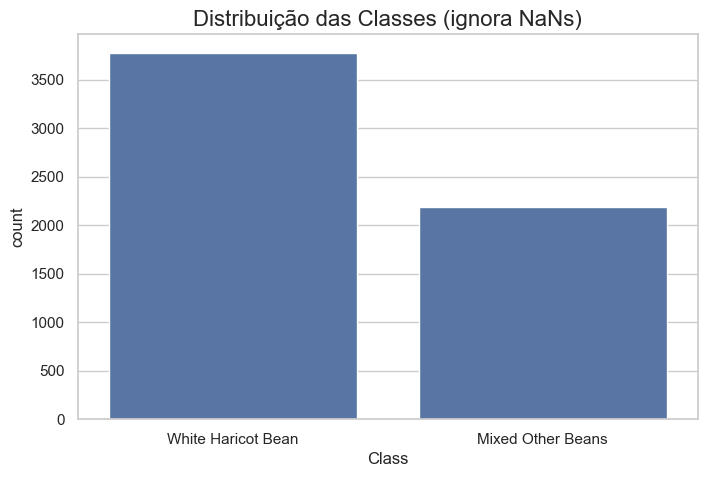

In [4]:

print("--- Contagem da Variável Alvo ('Class') ---")
print(df['Class'].value_counts())
print("\n")

# Plot visual da contagem
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Class')
ax.set_title("Distribuição das Classes (ignora NaNs)", fontsize=16)
plt.show()

### 3.3 Feature distribution

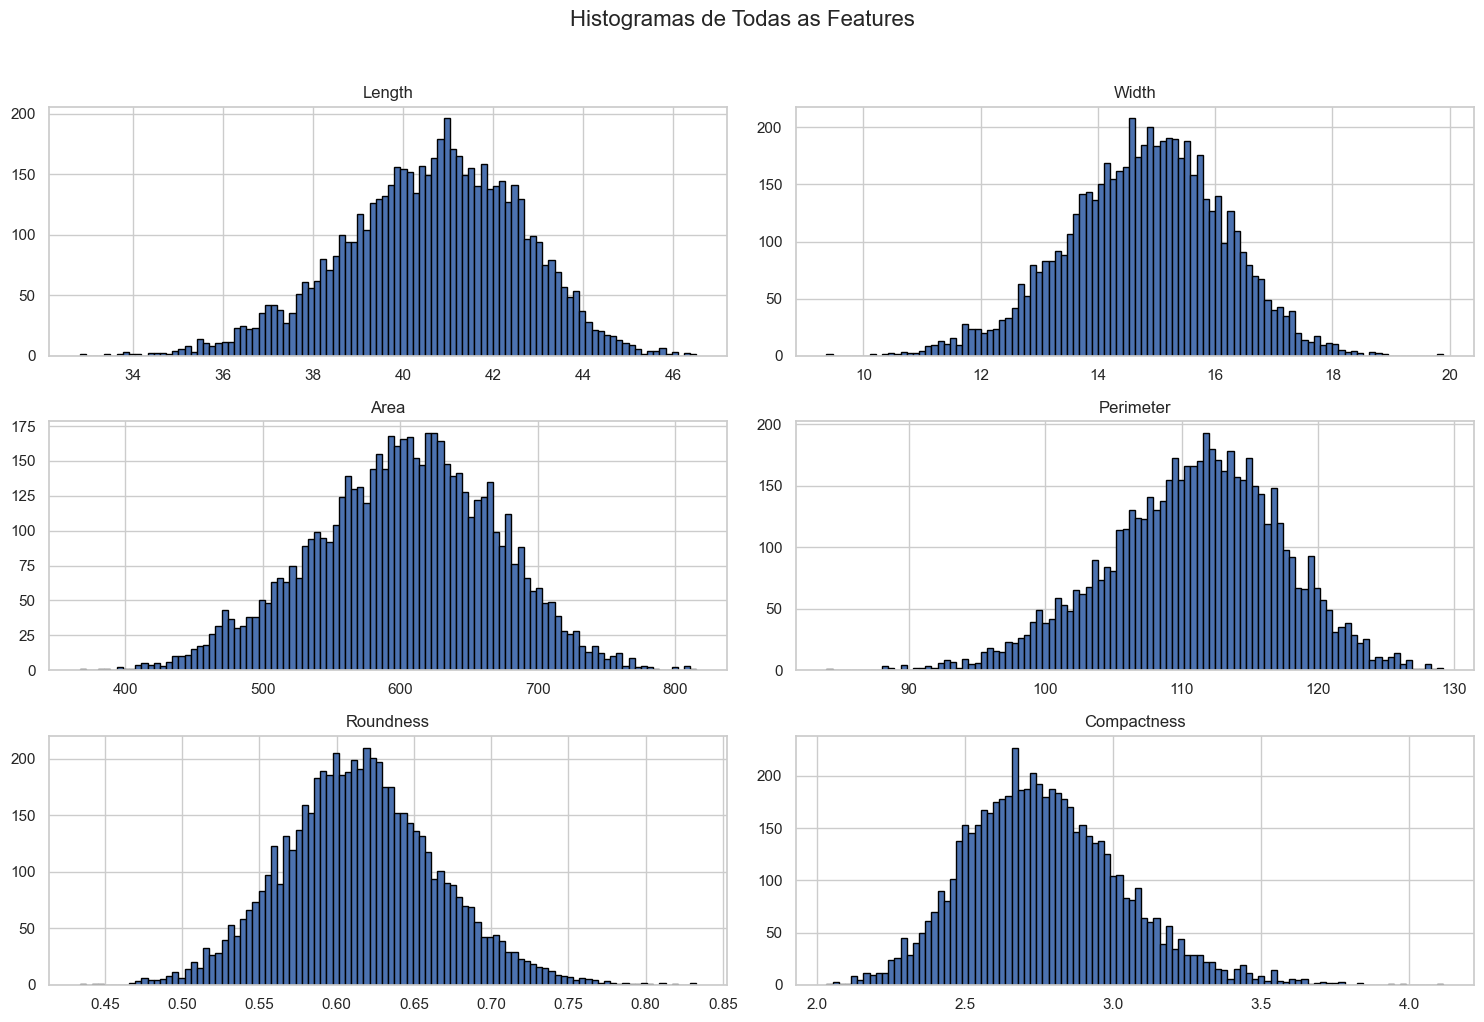

In [5]:
features = ['Length', 'Width', 'Area', 'Perimeter', 'Roundness', 'Compactness']

df[features].hist(figsize=(15, 10), bins=100, edgecolor='black')
plt.suptitle("Histogramas de Todas as Features", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### 3.4 Feature vs Label (Numerical analisys)

In [6]:
print("--- Sumário Estatístico por Classe ---")
estatisticas_por_classe = df.groupby('Class').describe()
print(estatisticas_por_classe.T)

--- Sumário Estatístico por Classe ---
Class              Mixed Other Beans  White Haricot Bean
Length      count        2187.000000         3759.000000
            mean           39.160353           41.512137
            std             1.744974            1.489909
            min            32.818372           36.223198
            25%            38.049458           40.495589
            50%            39.157144           41.499636
            75%            40.287030           42.530719
            max            45.495875           46.520909
Width       count        2179.000000         3764.000000
            mean           14.112545           15.196536
            std             1.353678            1.137787
            min             9.368682           11.057259
            25%            13.155419           14.414640
            50%            14.120176           15.212042
            75%            15.035728           15.968454
            max            18.452117           19

### 3.5 Feature vs Label (Boxplots)


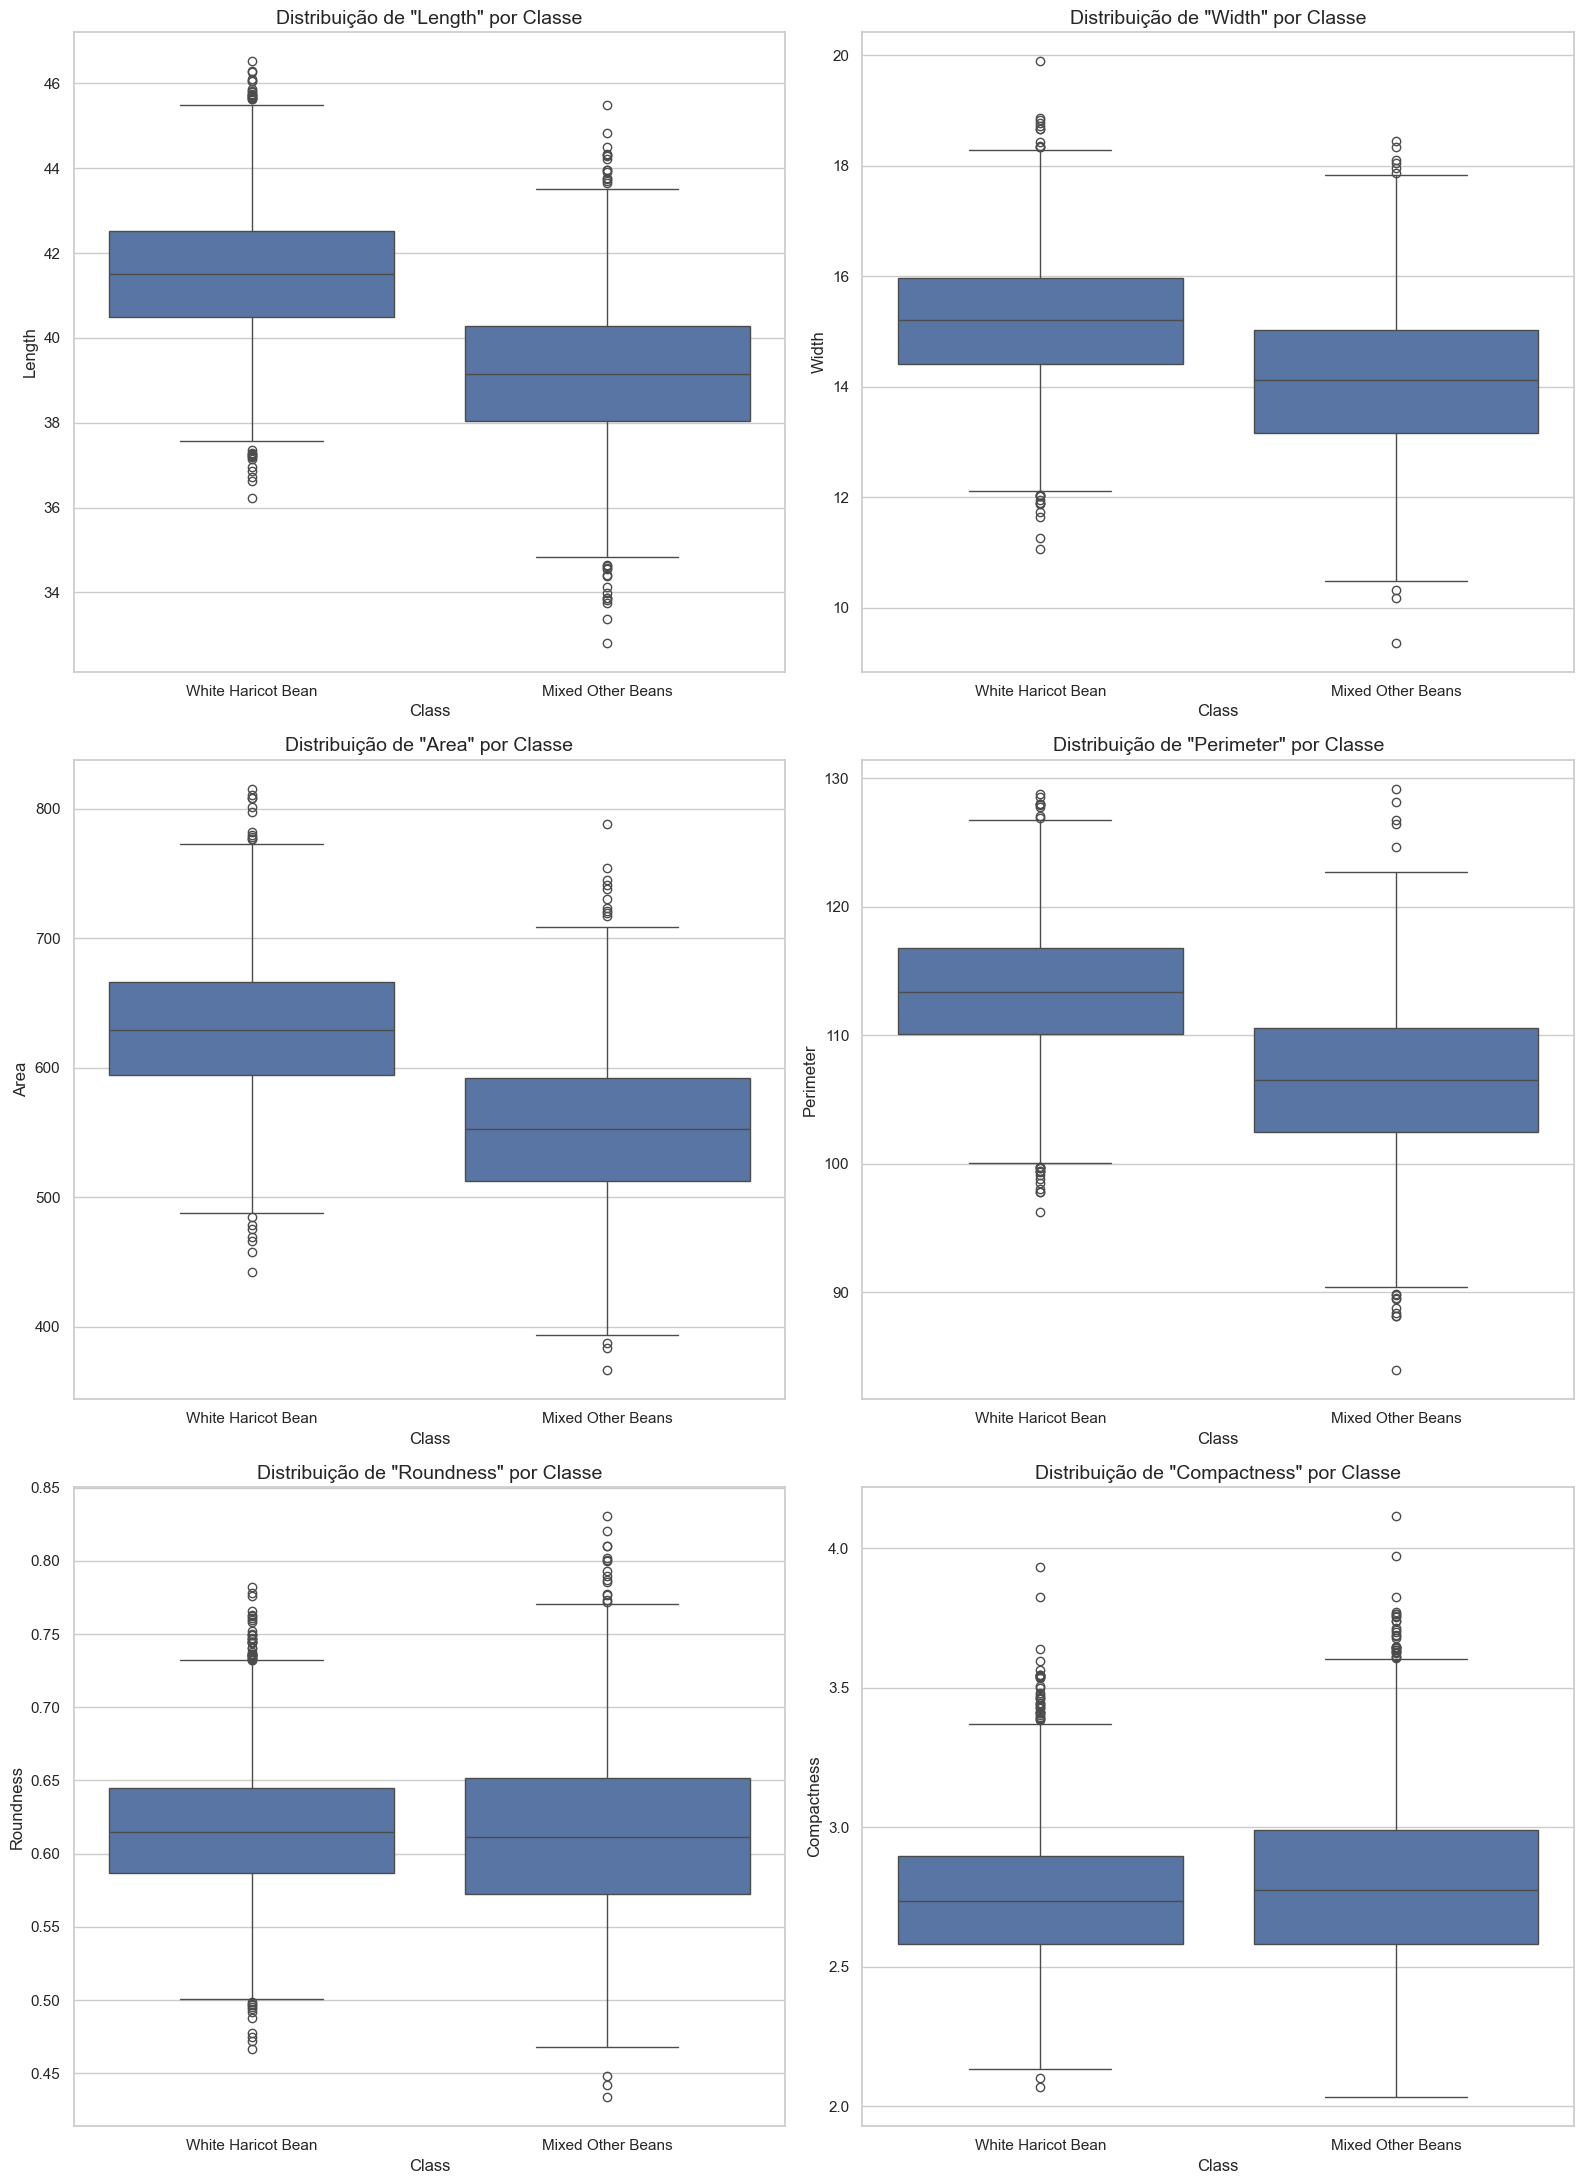

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(16, 22))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='Class', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'Distribuição de "{feature}" por Classe', fontsize=14)

plt.tight_layout() 
plt.show()

### 3.6 Feature vs Label (Density Plots)



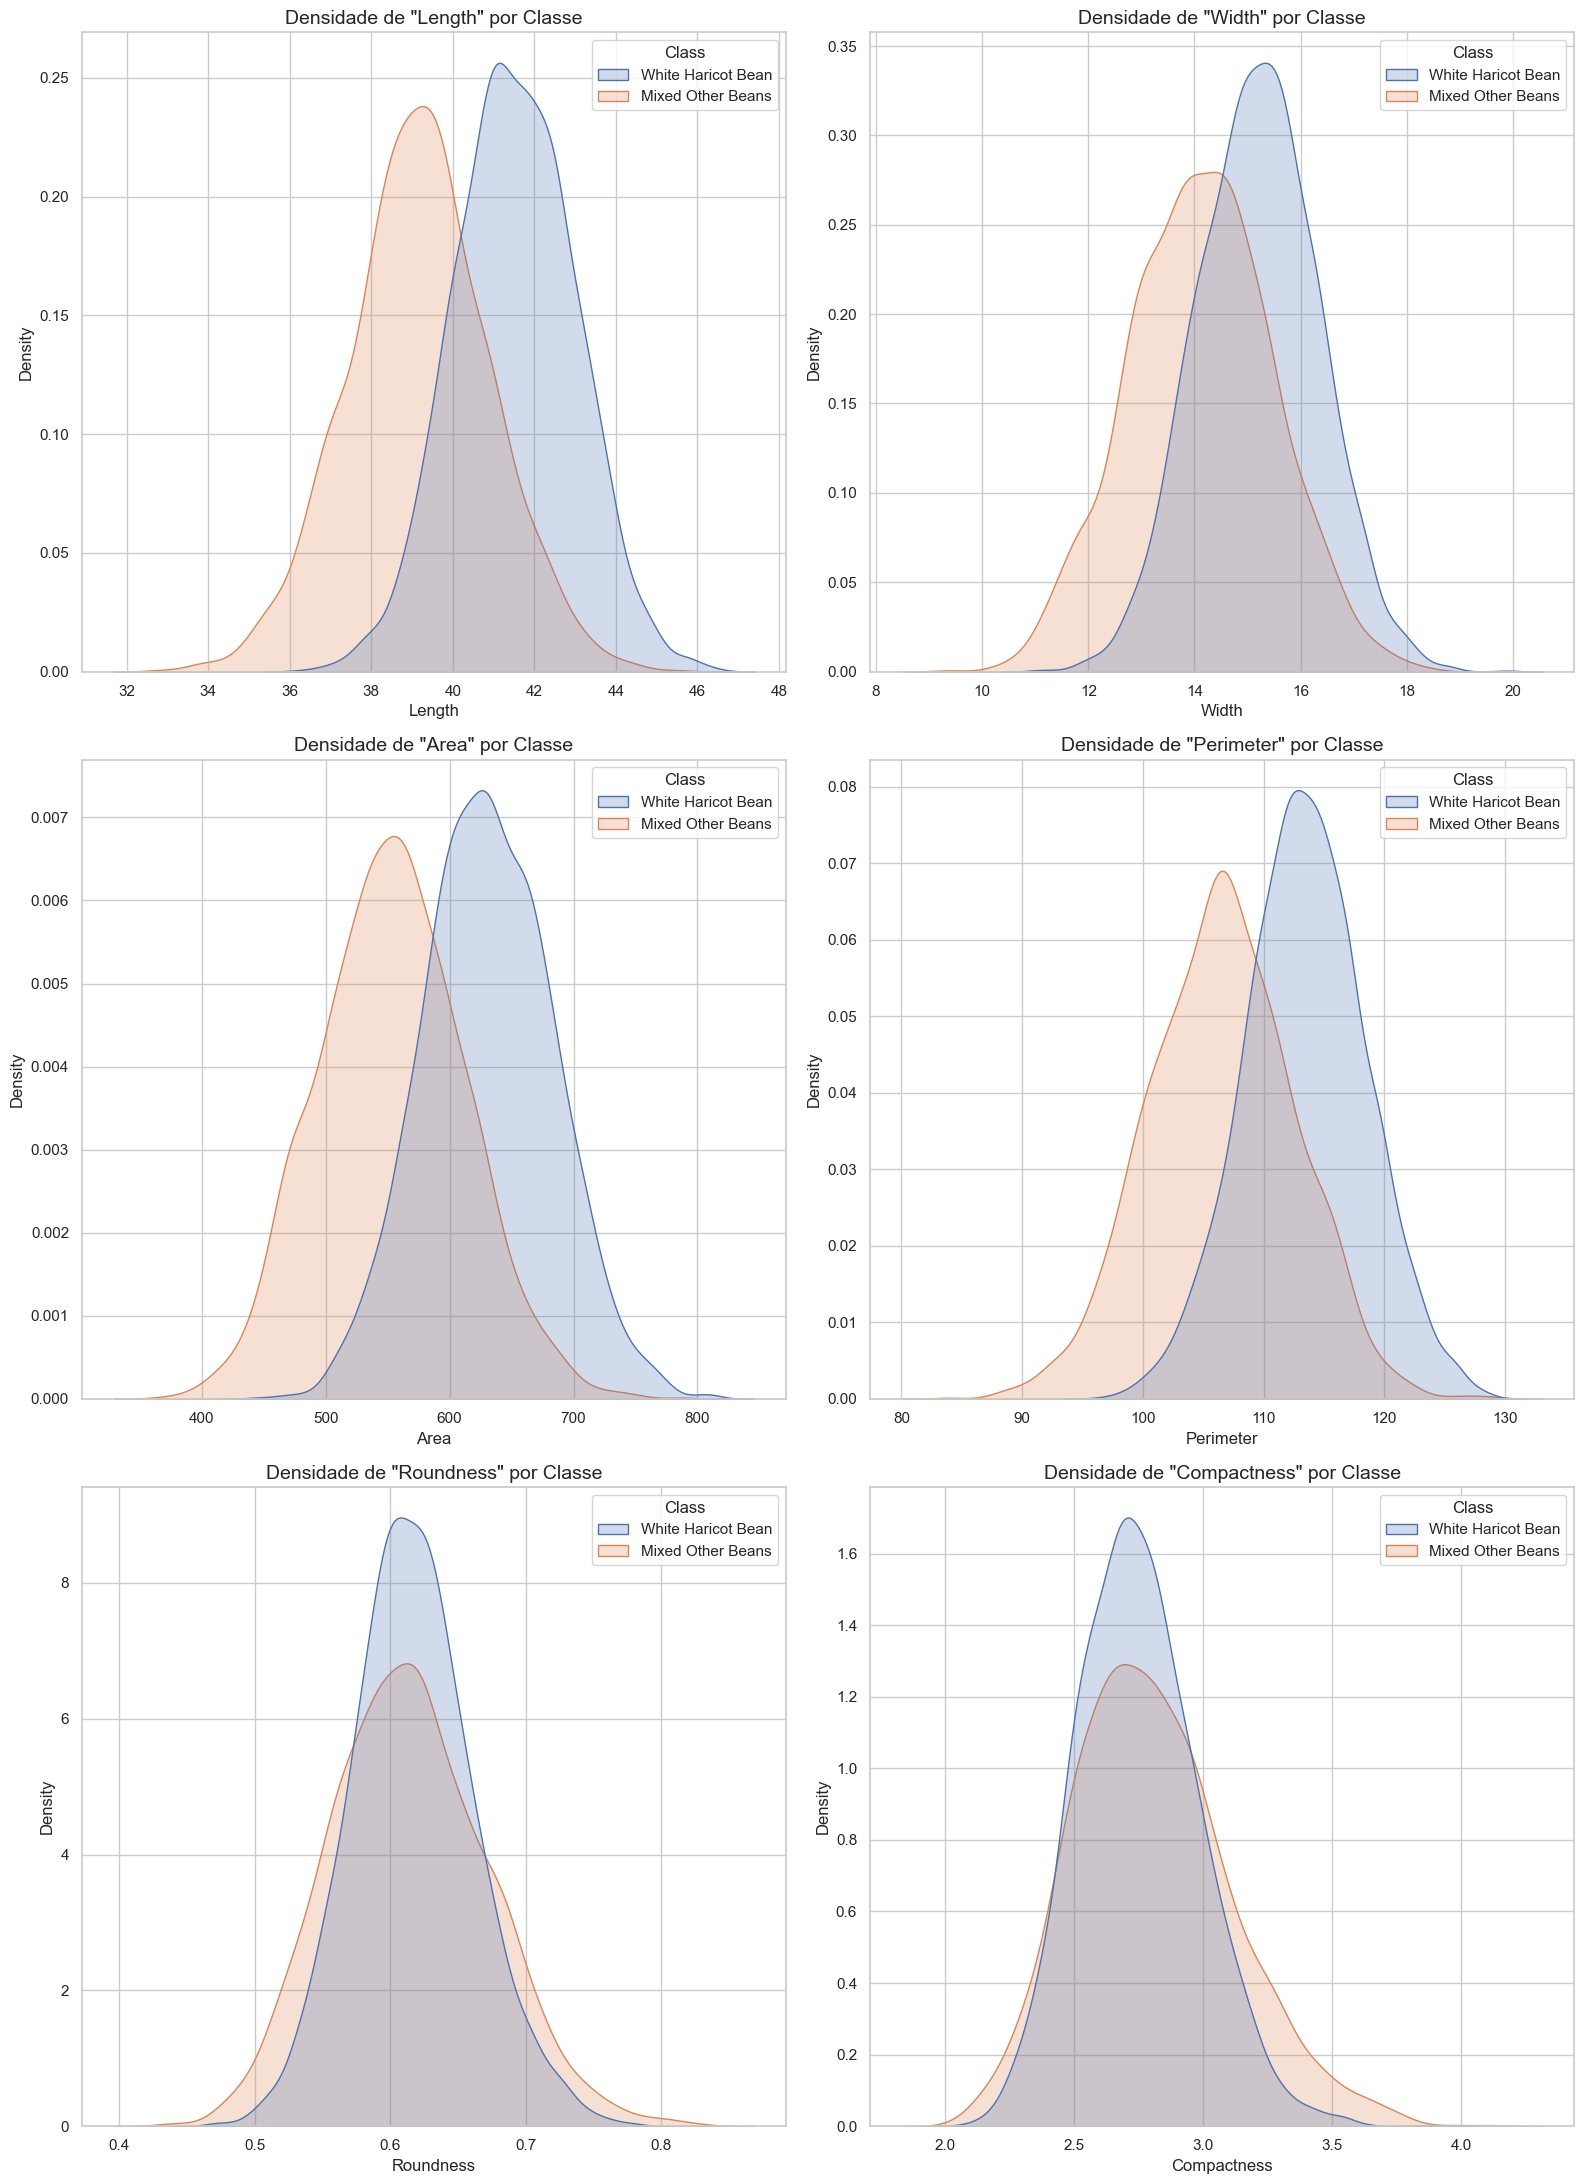

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(16, 22))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.kdeplot(data=df, x=feature, hue='Class', fill=True, 
                common_norm=False, ax=axes[i], legend=True)
    axes[i].set_title(f'Densidade de "{feature}" por Classe', fontsize=14)

plt.tight_layout()
plt.show()

### 3.7 Feature vs Feature (Correlation matrix)

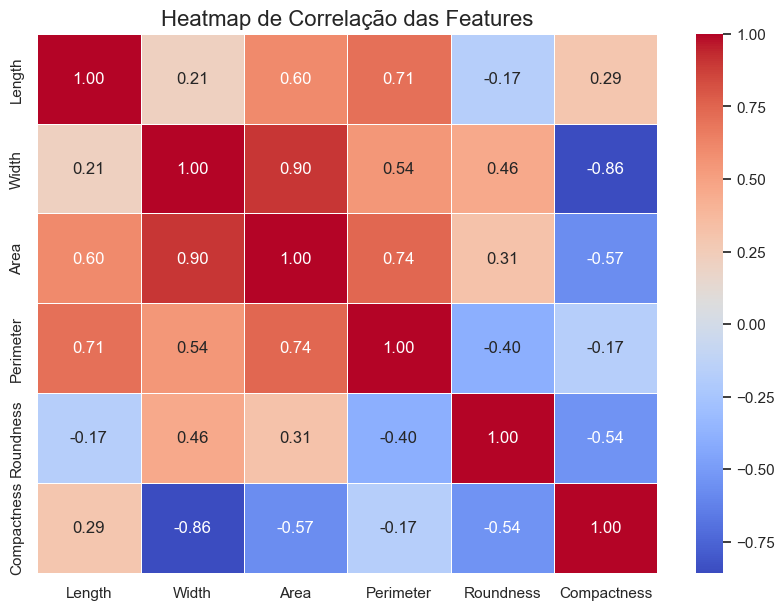

In [9]:
plt.figure(figsize=(10, 7))
corr_matrix = df[features].corr() 
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap de Correlação das Features", fontsize=16)
plt.show()

### 3.8 Feature vs Feature (Pairplot)

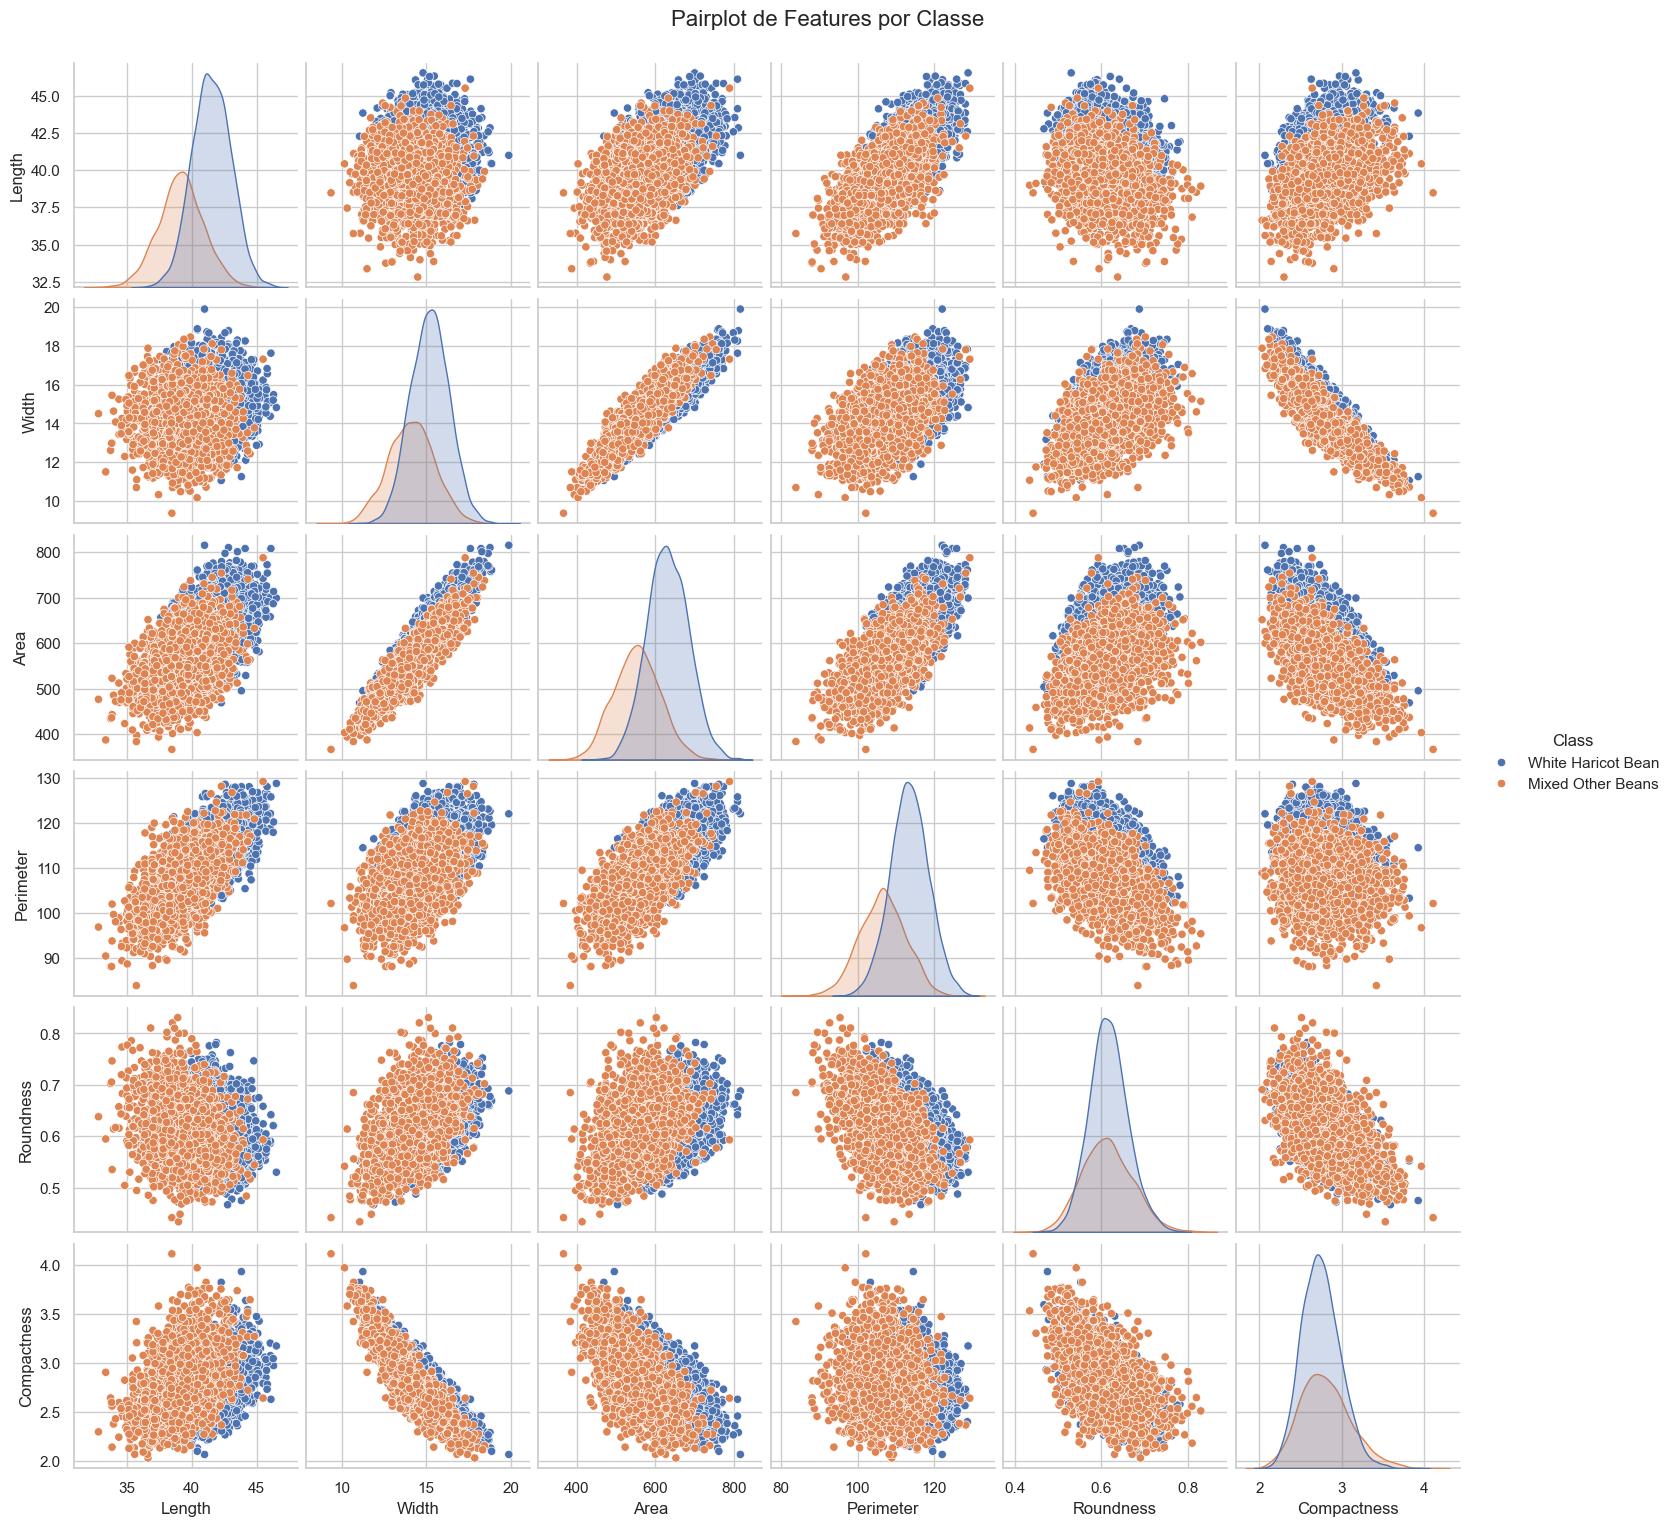

In [10]:
sns.pairplot(data=df.dropna(subset=['Class']),
             hue='Class', 
             vars=features)
plt.suptitle("Pairplot de Features por Classe", y=1.02, fontsize=16)
plt.show()

# Label encoding

### 4.1 Binary Target Conversion (White beans=1, others=0)

In [ ]:
df_clean = df.dropna().copy()

df_clean.loc[:, "Target"] = (df_clean["Class"] == "White Haricot Bean").astype(int)

print(df_clean["Target"].value_counts())


## Correlation & Redundancy Analysis

### 5.1 Spearman Correlation Analysis

=== Correlação de Spearman entre Features ===

      Feature 1    Feature 2  Spearman Corr    |Corr|
13         Area        Width       0.892973  0.892973
31  Compactness        Width      -0.841605  0.841605
15         Area    Perimeter       0.731816  0.731816
3        Length    Perimeter       0.686551  0.686551
12         Area       Length       0.588497  0.588497
17         Area  Compactness      -0.537897  0.537897
19    Perimeter        Width       0.532358  0.532358
34  Compactness    Roundness      -0.523057  0.523057
25    Roundness        Width       0.453381  0.453381
22    Perimeter    Roundness      -0.365520  0.365520 



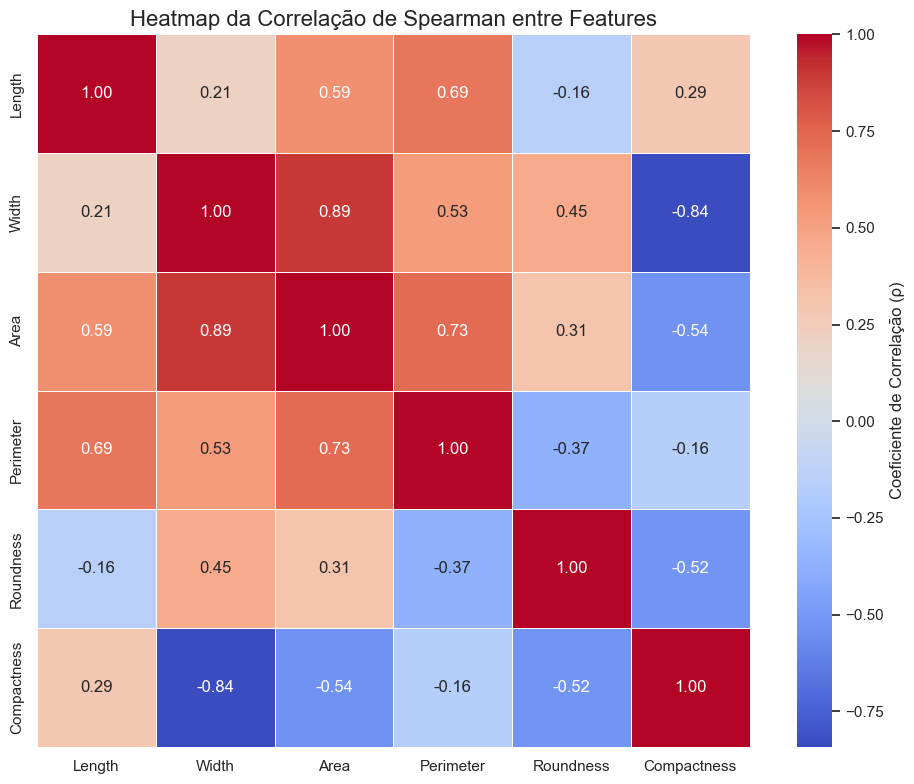

In [11]:


def analyze_spearman_correlation(df, top_n=10, figsize=(10, 8)):
    """
    Calcula e apresenta a correlação de Spearman entre features numéricas.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Dataset original.
    top_n : int
        Número de pares de features mais correlacionadas a mostrar.
    figsize : tuple
        Tamanho da figura do heatmap.
    """

    # Selecionar colunas numéricas
    numeric_cols = df_clean.select_dtypes(include=['number']).columns

    print("=== Correlação de Spearman entre Features ===\n")

    # Matriz de correlação
    corr_matrix = df_clean[numeric_cols].corr(method='spearman')

    # Criar tabela de pares
    corr_pairs = (
        corr_matrix.stack()
        .reset_index()
        .rename(columns={'level_0': 'Feature 1', 'level_1': 'Feature 2', 0: 'Spearman Corr'})
    )

    # Remover duplicados e self-correlation
    corr_pairs = corr_pairs[corr_pairs['Feature 1'] < corr_pairs['Feature 2']]
    corr_pairs['|Corr|'] = corr_pairs['Spearman Corr'].abs()

    # Ordenar por correlação absoluta
    corr_pairs = corr_pairs.sort_values(by='|Corr|', ascending=False)

    # Mostrar top N correlações
    print(corr_pairs.head(top_n), "\n")

    # === Plot ===
    plt.figure(figsize=figsize)
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "Coeficiente de Correlação (ρ)"},
    )
    plt.title("Heatmap da Correlação de Spearman entre Features", fontsize=16)
    plt.tight_layout()
    plt.show()

    # Devolver a matriz + correlações ordenadas (útil para mais análises)
    return corr_matrix, corr_pairs


# Remover NaNs
df_clean = df.dropna()    
corr_matrix, corr_pairs = analyze_spearman_correlation(df_clean)

### 5.2 Detecting Redundant Features

In [12]:

def detect_redundant_features(df, threshold=0.85):
    """
    Deteta pares de features com alta correlação (|ρ| >= threshold)
    e decide automaticamente qual remover com base em heurísticas.

    Retorna:
      - redundant_pairs: lista de pares redundantes
      - to_remove: lista final de features a eliminar
      - to_keep: lista de features mantidas
    """

    df_clean = df.dropna()
    numeric_cols = df_clean.select_dtypes(include=['number']).columns
    corr_matrix = df_clean[numeric_cols].corr(method='spearman').abs()

    redundant_pairs = []
    to_remove = set()

    # Encontrar pares redundantes
    for col1 in corr_matrix.columns:
        for col2 in corr_matrix.columns:
            if col1 < col2 and corr_matrix.loc[col1, col2] >= threshold:
                redundant_pairs.append((col1, col2, corr_matrix.loc[col1, col2]))

                # Se já decidimos remover algum deles, skip
                if col1 in to_remove or col2 in to_remove:
                    continue

                # --- Critérios de eliminação ---

                # 1) Missing values
                na1 = df[col1].isna().sum()
                na2 = df[col2].isna().sum()
                if na1 != na2:
                    remove = col1 if na1 > na2 else col2
                    to_remove.add(remove)
                    continue

                # 2) Variância
                var1 = df[col1].var()
                var2 = df[col2].var()
                if var1 != var2:
                    remove = col1 if var1 < var2 else col2
                    to_remove.add(remove)
                    continue

                # 3) Grau de redundância com outras features
                deg1 = (corr_matrix[col1] >= threshold).sum()
                deg2 = (corr_matrix[col2] >= threshold).sum()
                if deg1 != deg2:
                    remove = col1 if deg1 > deg2 else col2
                    to_remove.add(remove)
                    continue

                # 4) Critério neutro (alfabético)
                remove = max(col1, col2)
                to_remove.add(remove)

    to_keep = [c for c in numeric_cols if c not in to_remove]

    return redundant_pairs, sorted(list(to_remove)), to_keep
pairs, remove, keep = detect_redundant_features(df_clean, threshold=0.8)

print("\n=== Pares altamente correlacionados ===")
for p in pairs:
    print(p)

print("\n=== Features a remover ===")
print(remove)

print("\n=== Features a manter ===")
print(keep)



=== Pares altamente correlacionados ===
('Area', 'Width', np.float64(0.8929731539064266))
('Compactness', 'Width', np.float64(0.8416047937794481))

=== Features a remover ===
['Width']

=== Features a manter ===
['Length', 'Area', 'Perimeter', 'Roundness', 'Compactness']


### 5.3 Feature Importance via ReliefF

=== ReliefF Feature Selection ===

📊 ReliefF Scores (ordenados por importância):

    Feature  ReliefF Score
     Length       0.018371
  Perimeter       0.013025
  Roundness       0.012901
       Area       0.012547
Compactness       0.009582
      Width       0.008091


💡 Interpretação dos Scores:
- Scores POSITIVOS: Feature ajuda a distinguir as classes
- Scores NEGATIVOS: Feature pode atrapalhar a classificação
- Quanto MAIOR o score, mais importante a feature



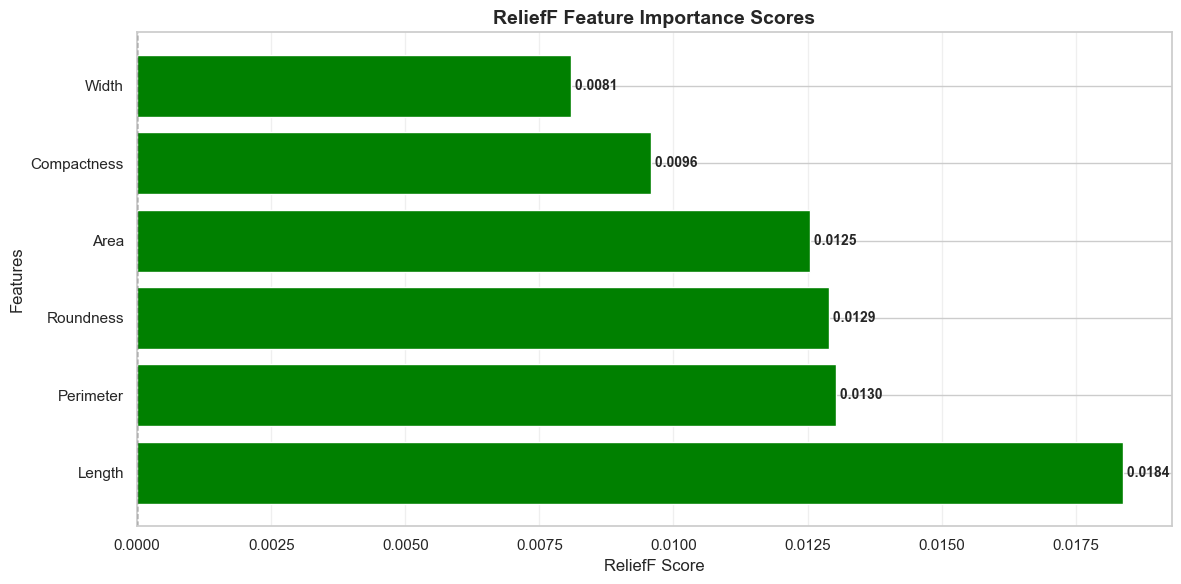


✅ Features ÚTEIS (6): Length, Perimeter, Roundness, Area, Compactness, Width

✅ Todas as features têm score positivo - todas são úteis!


In [13]:

print("=== ReliefF Feature Selection ===\n")

# Preparar dados (usar todas as features originais)
all_features = ['Length', 'Width', 'Area', 'Perimeter', 'Roundness', 'Compactness']
X_relief = df_clean[all_features].values
# Criar target temporário diretamente aqui
y_relief = (df_clean["Class"] == "White Haricot Bean").astype(int).values


# Aplicar ReliefF
relief = ReliefF(n_neighbors=10, n_features_to_select=len(all_features))
relief.fit(X_relief, y_relief)

# Obter scores
feature_scores = pd.DataFrame({
    'Feature': all_features,
    'ReliefF Score': relief.feature_importances_
}).sort_values('ReliefF Score', ascending=False)

print("📊 ReliefF Scores (ordenados por importância):\n")
print(feature_scores.to_string(index=False))
print()

# Interpretação
print("\n💡 Interpretação dos Scores:")
print("- Scores POSITIVOS: Feature ajuda a distinguir as classes")
print("- Scores NEGATIVOS: Feature pode atrapalhar a classificação")
print("- Quanto MAIOR o score, mais importante a feature")
print()

# Visualização
plt.figure(figsize=(12, 6))
colors = ['green' if score > 0 else 'red' for score in feature_scores['ReliefF Score']]
bars = plt.barh(feature_scores['Feature'], feature_scores['ReliefF Score'], color=colors)
plt.xlabel('ReliefF Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('ReliefF Feature Importance Scores', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)

# Adicionar valores nas barras
for i, (feature, score) in enumerate(zip(feature_scores['Feature'], feature_scores['ReliefF Score'])):
    plt.text(score, i, f' {score:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Recomendações
positive_features = feature_scores[feature_scores['ReliefF Score'] > 0]['Feature'].tolist()
negative_features = feature_scores[feature_scores['ReliefF Score'] <= 0]['Feature'].tolist()

print(f"\n✅ Features ÚTEIS ({len(positive_features)}): {', '.join(positive_features)}")
if negative_features:
    print(f"❌ Features PREJUDICIAIS ({len(negative_features)}): {', '.join(negative_features)}")
    print("\n⚠️ Considera remover as features com score negativo para melhorar o modelo!")
else:
    print("\n✅ Todas as features têm score positivo - todas são úteis!")

# Feature Engineering

### 6.1 Creating Engineered Features

In [15]:


def create_engineered_features(df):
    """
    Cria features engineered para o dataset de feijões
    """
    df_eng = df.copy()

    df_eng['Length_Squared'] = df_eng['Length'] ** 2

    
    """
    # === 1. RATIOS E COMBINAÇÕES ===
    df_eng['Aspect_Ratio'] = df_eng['Length'] / (df_eng['Width'] + 1e-6)
    df_eng['Area_Perimeter_Ratio'] = df_eng['Area'] / (df_eng['Perimeter'] + 1e-6)
    df_eng['Elongation'] = (df_eng['Length'] - df_eng['Width']) / (df_eng['Length'] + df_eng['Width'] + 1e-6)
    df_eng['Length_Width_Product'] = df_eng['Length'] * df_eng['Width']
    
    # === 2. FEATURES GEOMÉTRICAS ===
    df_eng['Equiv_Diameter'] = np.sqrt(4 * df_eng['Area'] / np.pi)
    df_eng['Circularity_Deviation'] = np.abs(1 - df_eng['Roundness'])
    df_eng['Normalized_Area'] = df_eng['Area'] / (df_eng['Perimeter'] ** 2 + 1e-6)
    df_eng['Inverse_Compactness'] = 1 / (df_eng['Compactness'] + 1e-6)
    
    # === 3. TRANSFORMAÇÕES NÃO-LINEARES ===
    df_eng['Log_Area'] = np.log1p(df_eng['Area'])
    df_eng['Log_Perimeter'] = np.log1p(df_eng['Perimeter'])
    df_eng['Sqrt_Area'] = np.sqrt(df_eng['Area'])
    df_eng['Sqrt_Perimeter'] = np.sqrt(df_eng['Perimeter'])
    df_eng['Length_Squared'] = df_eng['Length'] ** 2
    df_eng['Width_Squared'] = df_eng['Width'] ** 2
    
    # === 4. INTERAÇÕES ENTRE COMPACTNESS E ROUNDNESS ===
    df_eng['Compact_Round_Product'] = df_eng['Compactness'] * df_eng['Roundness']
    df_eng['Compact_Round_Ratio'] = df_eng['Compactness'] / (df_eng['Roundness'] + 1e-6)
    
    # === 5. ESTATÍSTICAS LOCAIS ===
    df_eng['Area_Deviation'] = df_eng['Area'] - df_eng['Area'].mean()
    df_eng['Length_Deviation'] = df_eng['Length'] - df_eng['Length'].mean()
    df_eng['Width_Deviation'] = df_eng['Width'] - df_eng['Width'].mean()
    df_eng['Perimeter_Deviation'] = df_eng['Perimeter'] - df_eng['Perimeter'].mean()
    """
    
    return df_eng

# Aplicar feature engineering
print("=== Criando Features Engineered ===\n")
df_engineered = create_engineered_features(df_clean)

# Ver novas features criadas
original_cols = df_clean.columns.tolist()
new_features = [col for col in df_engineered.columns if col not in original_cols]

print(f"✅ Features ORIGINAIS: {len(original_cols)}")
print(f"✅ Features NOVAS: {len(new_features)}")
print(f"✅ TOTAL de features: {len(df_engineered.columns)}")
print(f"\n📋 Novas features criadas:\n")
for i, feat in enumerate(new_features, 1):
    print(f"  {i}. {feat}")

=== Criando Features Engineered ===

✅ Features ORIGINAIS: 8
✅ Features NOVAS: 1
✅ TOTAL de features: 9

📋 Novas features criadas:

  1. Length_Squared


### 6.2 Evaluating Engineered Features

=== ReliefF - Análise de TODAS as Features (Originais + Engineered) ===

📊 Total de features a analisar: 7

🏆 TOP 15 Features Mais Importantes:

✅ Length_Squared                 | Score:  0.01516
✅ Length                         | Score:  0.01483
✅ Roundness                      | Score:  0.01483
✅ Perimeter                      | Score:  0.01408
✅ Area                           | Score:  0.01268
✅ Compactness                    | Score:  0.00989
✅ Width                          | Score:  0.00986


📋 TODAS as Features com Scores (ordenadas por importância):

✅ Length_Squared                 | Score:  0.01516
✅ Length                         | Score:  0.01483
✅ Roundness                      | Score:  0.01483
✅ Perimeter                      | Score:  0.01408
✅ Area                           | Score:  0.01268
✅ Compactness                    | Score:  0.00989
✅ Width                          | Score:  0.00986


📈 Estatísticas:
  ✅ Features POSITIVAS (úteis): 7
  ❌ Features NEGATIVAS (pr

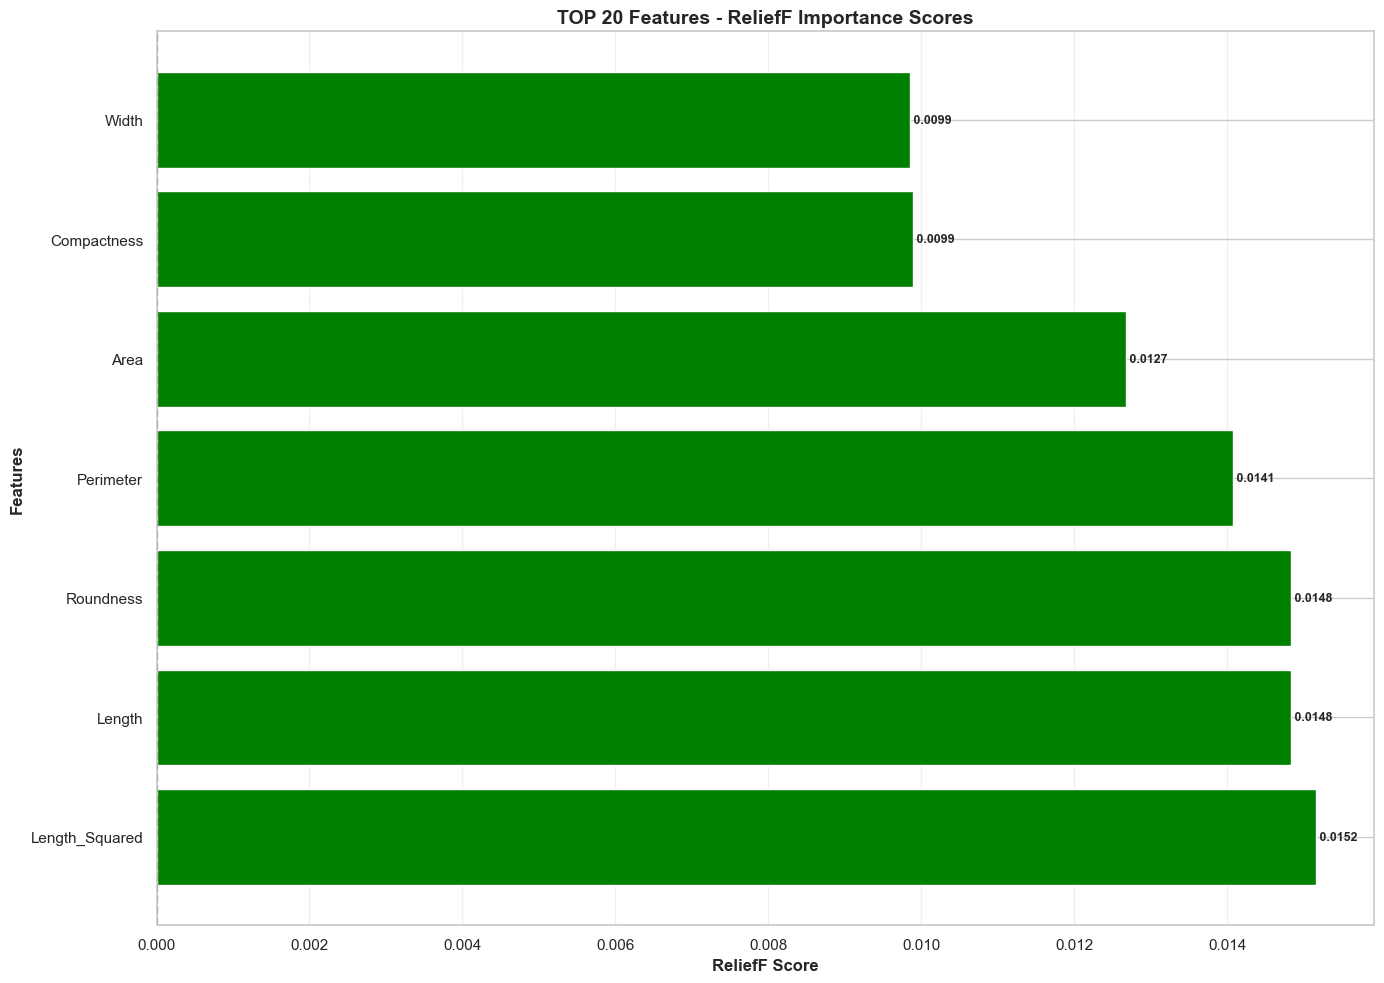


✅ Análise ReliefF concluída!


In [16]:

print("=== ReliefF - Análise de TODAS as Features (Originais + Engineered) ===\n")

# Selecionar apenas features numéricas (excluir 'Class' e 'Target' se existirem)
all_numeric_features = df_engineered.select_dtypes(include=['number']).columns.tolist()
if 'Target' in all_numeric_features:
    all_numeric_features.remove('Target')

print(f"📊 Total de features a analisar: {len(all_numeric_features)}\n")

# Preparar dados
X_all = df_engineered[all_numeric_features].values
y_all = (df_engineered["Class"] == "White Haricot Bean").astype(int).values

# Aplicar ReliefF
relief_all = ReliefF(n_neighbors=10, n_features_to_select=len(all_numeric_features))
relief_all.fit(X_all, y_all)

# Criar DataFrame com scores
importance_df = pd.DataFrame({
    'Feature': all_numeric_features,
    'ReliefF Score': relief_all.feature_importances_
}).sort_values('ReliefF Score', ascending=False)

# Mostrar TOP 15 features
print("🏆 TOP 15 Features Mais Importantes:\n")
print("="*60)
for i, row in importance_df.head(15).iterrows():
    emoji = "✅" if row['ReliefF Score'] > 0 else "❌"
    print(f"{emoji} {row['Feature']:30s} | Score: {row['ReliefF Score']:8.5f}")
print("="*60)

# Mostrar TODAS as features com scores
print("\n\n📋 TODAS as Features com Scores (ordenadas por importância):\n")
print("="*60)
for i, row in importance_df.iterrows():
    emoji = "✅" if row['ReliefF Score'] > 0 else "❌"
    print(f"{emoji} {row['Feature']:30s} | Score: {row['ReliefF Score']:8.5f}")
print("="*60)

# Estatísticas
positive_features = importance_df[importance_df['ReliefF Score'] > 0]
negative_features = importance_df[importance_df['ReliefF Score'] <= 0]

print(f"\n\n📈 Estatísticas:")
print(f"  ✅ Features POSITIVAS (úteis): {len(positive_features)}")
print(f"  ❌ Features NEGATIVAS (prejudiciais): {len(negative_features)}")
print(f"  📊 Score MÁXIMO: {importance_df['ReliefF Score'].max():.5f} ({importance_df.iloc[0]['Feature']})")
print(f"  📉 Score MÍNIMO: {importance_df['ReliefF Score'].min():.5f} ({importance_df.iloc[-1]['Feature']})")

# Visualização - TOP 20
plt.figure(figsize=(14, 10))
top_20 = importance_df.head(20)
colors = ['green' if score > 0 else 'red' for score in top_20['ReliefF Score']]
bars = plt.barh(range(len(top_20)), top_20['ReliefF Score'], color=colors)
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('ReliefF Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('TOP 20 Features - ReliefF Importance Scores', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.grid(axis='x', alpha=0.3)

# Adicionar valores nas barras
for i, (idx, row) in enumerate(top_20.iterrows()):
    score = row['ReliefF Score']
    plt.text(score, i, f' {score:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("✅ Análise ReliefF concluída!")
print("="*60)

### 6.3 Correlation Between Features



=== Correlação de Spearman entre Features ===

      Feature 1    Feature 2  Spearman Corr    |Corr|
15         Area        Width       0.892973  0.892973
36  Compactness        Width      -0.841605  0.841605
17         Area    Perimeter       0.731816  0.731816
3        Length    Perimeter       0.686551  0.686551
14         Area       Length       0.588497  0.588497
6        Length       Target       0.583520  0.583520
20         Area       Target       0.569030  0.569030
19         Area  Compactness      -0.537897  0.537897
22    Perimeter        Width       0.532358  0.532358
39  Compactness    Roundness      -0.523057  0.523057
27    Perimeter       Target       0.522162  0.522162
29    Roundness        Width       0.453381  0.453381
43       Target        Width       0.384632  0.384632
25    Perimeter    Roundness      -0.365520  0.365520
18         Area    Roundness       0.309700  0.309700
35  Compactness       Length       0.294381  0.294381
1        Length        Width       

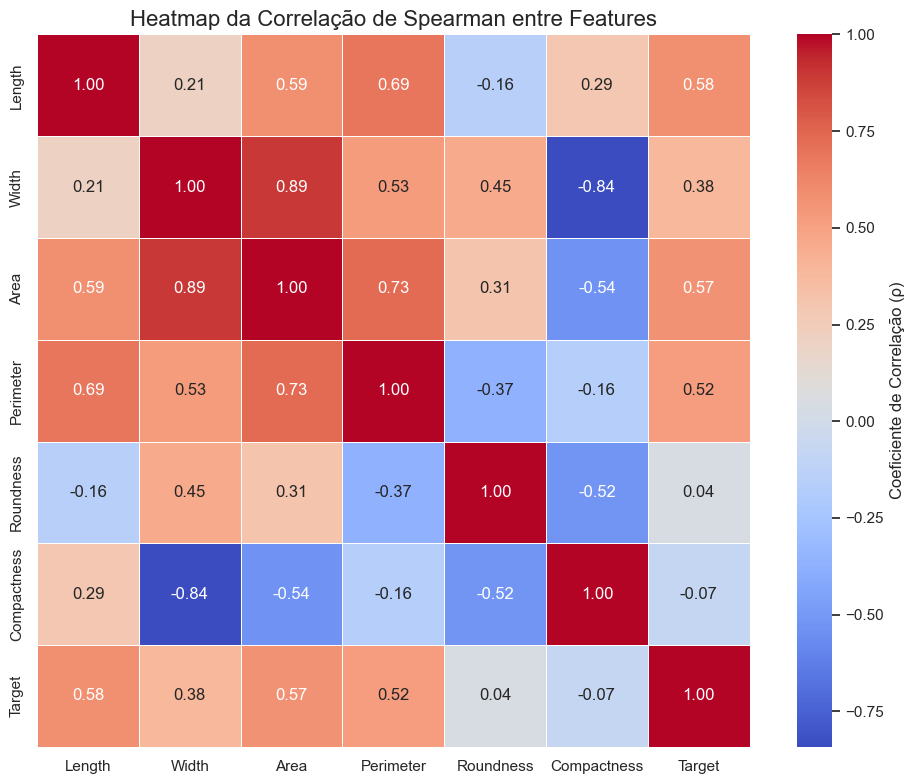

(               Length     Width      Area  Perimeter  Roundness  Compactness  \
 Length       1.000000  0.205870  0.588497   0.686551  -0.155282     0.294381   
 Width        0.205870  1.000000  0.892973   0.532358   0.453381    -0.841605   
 Area         0.588497  0.892973  1.000000   0.731816   0.309700    -0.537897   
 Perimeter    0.686551  0.532358  0.731816   1.000000  -0.365520    -0.161110   
 Roundness   -0.155282  0.453381  0.309700  -0.365520   1.000000    -0.523057   
 Compactness  0.294381 -0.841605 -0.537897  -0.161110  -0.523057     1.000000   
 Target       0.583520  0.384632  0.569030   0.522162   0.037767    -0.074536   
 
                Target  
 Length       0.583520  
 Width        0.384632  
 Area         0.569030  
 Perimeter    0.522162  
 Roundness    0.037767  
 Compactness -0.074536  
 Target       1.000000  ,
       Feature 1    Feature 2  Spearman Corr    |Corr|
 15         Area        Width       0.892973  0.892973
 36  Compactness        Width      -0.8

In [17]:
analyze_spearman_correlation(df_engineered, top_n=30)

# Data Preparation for Modeling

### 7.1 Defining X and y

In [18]:
features = ['Length', 'Width', 'Area', 'Perimeter', 'Roundness', 'Compactness']


#X = df_clean[features]
X = df_engineered[features]
#y = df_clean["Target"]
y = df_engineered["Target"]

#print(X.head())
#print(".......")
#print(y.head())


### 7.2 Train–Validation–Test Split

In [19]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,        # 25% vai para teste
    random_state=42,       # garante reprodutibilidade
    stratify=y             # mantém proporção das classes
)

print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste :", X_test.shape)


Tamanho do treino: (4357, 6)
Tamanho do teste : (1453, 6)


### 7.3 Feature Scaling

In [20]:

# Criar o normalizador
scaler = StandardScaler()

# Ajustar o scaler NO TREINO (fit) e transformar
X_train_scaled = scaler.fit_transform(X_train)

# Transformar o teste (usando os parâmetros do treino)
X_test_scaled = scaler.transform(X_test)

print("Treino normalizado shape:", X_train_scaled.shape)
print("Teste normalizado shape:", X_test_scaled.shape)


Treino normalizado shape: (4357, 6)
Teste normalizado shape: (1453, 6)


# Model Training and Evaluation

### 8.1 Decision Tree – Selecting the Best Depth

➡️ Melhor depth = 3 (Recall = 0.9325)


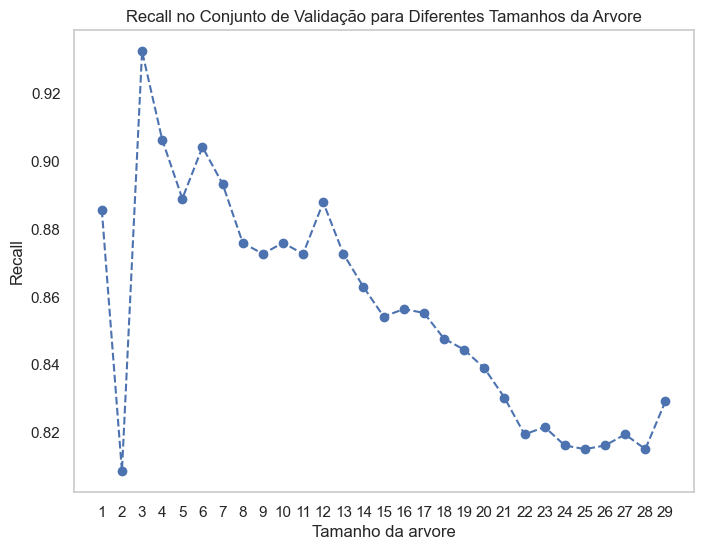

In [21]:



def DecisionTree_best_depth(X_train,X_test, y_train,y_test, depth_range):


    recalls = []

    for depth in depth_range:
        clf = DecisionTreeClassifier(max_depth=depth)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        score = recall_score(y_test, y_pred)
        recalls.append(score)

    best_index = np.argmax(recalls)
    best_depth = depth_range[best_index]
    best_recall = recalls[best_index]

    print(f"➡️ Melhor depth = {best_depth} (Recall = {best_recall:.4f})")

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(depth_range, recalls, marker='o', linestyle='--', color='b')
    plt.title("Recall no Conjunto de Validação para Diferentes Tamanhos da Arvore")
    plt.xlabel("Tamanho da arvore")
    plt.ylabel("Recall")
    plt.xticks(depth_range)
    plt.grid()
    plt.show()

    return best_depth

depth_range = list(range(1, 30))
best_depth=DecisionTree_best_depth(X_train_scaled, X_test_scaled, y_train,y_test, depth_range)

### 8.1.2 Training the Final Decision Tree

In [22]:

# Criar o modelo
dt = DecisionTreeClassifier(max_depth=best_depth,random_state=42)

# Treinar no conjunto de treino original
dt.fit(X_train_scaled, y_train)

print("Modelo Decision Tree treinado com sucesso!")


Modelo Decision Tree treinado com sucesso!


### 8.1.3 Making Predictions on the Test Set

In [23]:
y_pred_dt = dt.predict(X_test_scaled)


### 8.1.4 Evaluating the Decision Tree

In [24]:


def evaluate(y_true, y_pred, name):
    print(f"\n=== Avaliação do modelo: {name} ===")
    
    # Métricas globais
    print("\n--- Métricas Globais ---")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("F1-score :", f1_score(y_true, y_pred, average='weighted'))
    
    # Métricas por classe
    print("\n--- Métricas por Classe ---")
    print(classification_report(y_true, y_pred, target_names=["Mixed Beans", "White Haricot Bean"]))
    
    print("\nMatriz de Confusão:")
    print(confusion_matrix(y_true, y_pred))

evaluate(y_test, y_pred_dt, "Decision Tree")


=== Avaliação do modelo: Decision Tree ===

--- Métricas Globais ---
Accuracy : 0.8100481761871989
Precision: 0.8139720978972671
Recall   : 0.8100481761871989
F1-score : 0.8015424227108126

--- Métricas por Classe ---
                    precision    recall  f1-score   support

       Mixed Beans       0.84      0.60      0.70       534
White Haricot Bean       0.80      0.93      0.86       919

          accuracy                           0.81      1453
         macro avg       0.82      0.77      0.78      1453
      weighted avg       0.81      0.81      0.80      1453


Matriz de Confusão:
[[320 214]
 [ 62 857]]


### 8.1.5 Feature Importance Analysis

In [25]:
importances = dt.feature_importances_

for feature, importance in zip(features, importances):
    print(f"{feature}: {importance:.4f}")


Length: 0.7415
Width: 0.0000
Area: 0.2585
Perimeter: 0.0000
Roundness: 0.0000
Compactness: 0.0000


### 8.1.6 Visualizing the Decision Tree

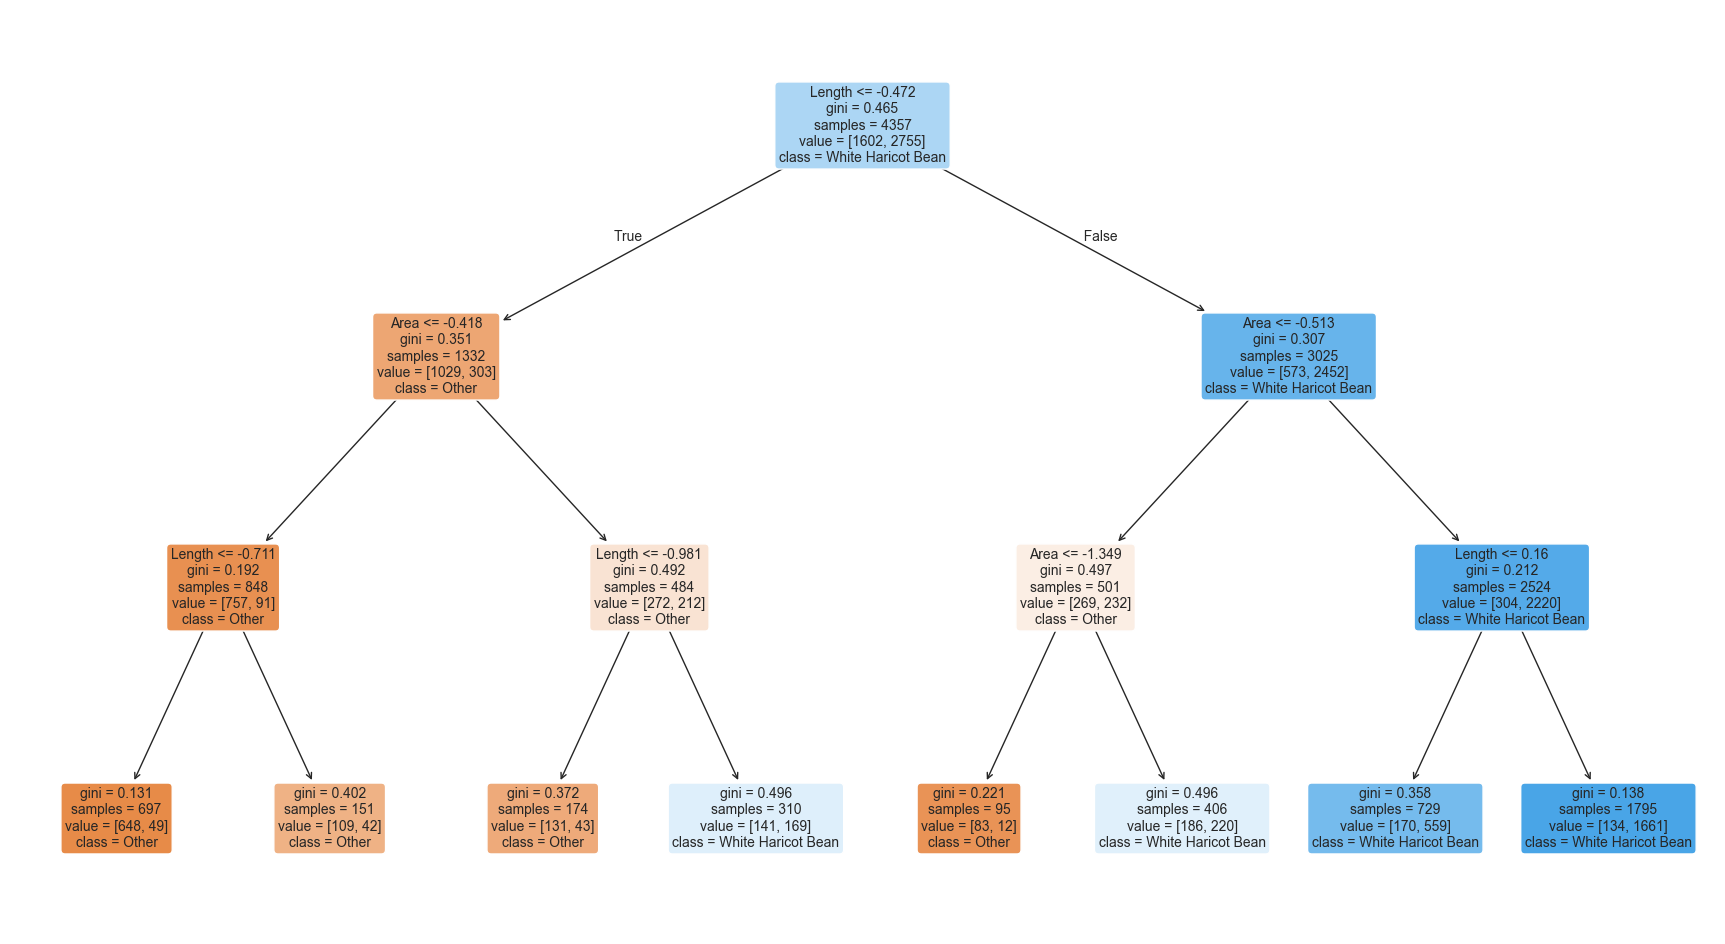

In [26]:


plt.figure(figsize=(22, 12))
plot_tree(dt, feature_names=features, class_names=["Other", "White Haricot Bean"], filled=True, rounded=True, fontsize=10)
plt.show()


### 8.2.1 Training and Predicting with k-NN

In [27]:

# Criar modelo KNN com k=5 (valor inicial típico)
knn = KNeighborsClassifier(n_neighbors=5)

# Treinar
knn.fit(X_train_scaled, y_train)

# Previsões
y_pred_knn = knn.predict(X_test_scaled)

print("Modelo KNN treinado com sucesso!")


Modelo KNN treinado com sucesso!


### 8.2.2 Evaluating the k-NN Classifier

In [28]:
evaluate(y_test, y_pred_knn, "KNN (k=5)")



=== Avaliação do modelo: KNN (k=5) ===

--- Métricas Globais ---
Accuracy : 0.8162422573984859
Precision: 0.814132318682292
Recall   : 0.8162422573984859
F1-score : 0.8140197764025567

--- Métricas por Classe ---
                    precision    recall  f1-score   support

       Mixed Beans       0.78      0.70      0.74       534
White Haricot Bean       0.84      0.88      0.86       919

          accuracy                           0.82      1453
         macro avg       0.81      0.79      0.80      1453
      weighted avg       0.81      0.82      0.81      1453


Matriz de Confusão:
[[374 160]
 [107 812]]


### 8.2.3 Tuning the Value of k (Hyperparameter Optimization)

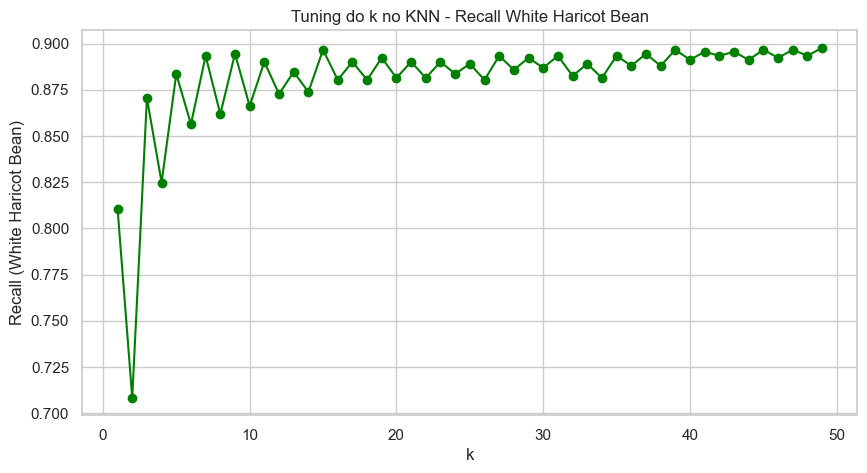

Melhor k para Recall (White Haricot Bean): 49 (Recall = 0.8977)


In [29]:
recalls_white_bean = []  # Recall para White Haricot Bean (classe 1)
k_values = range(1, 50)   

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    
    # Recall para White Haricot Bean (classe 1)
    recall_per_class = recall_score(y_test, y_pred_temp, average=None)
    recalls_white_bean.append(recall_per_class[1])

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_values, recalls_white_bean, marker="o", color='green')
plt.xlabel("k")
plt.ylabel("Recall (White Haricot Bean)")
plt.title("Tuning do k no KNN - Recall White Haricot Bean")
plt.grid(True)
plt.show()

best_k = k_values[recalls_white_bean.index(max(recalls_white_bean))]
print(f"Melhor k para Recall (White Haricot Bean): {best_k} (Recall = {max(recalls_white_bean):.4f})")


### 8.2.4 Training and Evaluating the Final k-NN Model

In [30]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_best_knn = knn_best.predict(X_test_scaled)

evaluate(y_test, y_pred_best_knn, f"KNN final (k={best_k})")



=== Avaliação do modelo: KNN final (k=49) ===

--- Métricas Globais ---
Accuracy : 0.817618719889883
Precision: 0.815816796366017
Recall   : 0.817618719889883
F1-score : 0.8141999448262489

--- Métricas por Classe ---
                    precision    recall  f1-score   support

       Mixed Beans       0.79      0.68      0.73       534
White Haricot Bean       0.83      0.90      0.86       919

          accuracy                           0.82      1453
         macro avg       0.81      0.79      0.80      1453
      weighted avg       0.82      0.82      0.81      1453


Matriz de Confusão:
[[363 171]
 [ 94 825]]


### 8.3.1 Defining Reduced Feature Set (Without Width)

In [31]:
features_reduced = ['Length', 'Area', 'Perimeter', 'Roundness', 'Compactness']

Xr = df_engineered[features_reduced]
#Xr = df_clean[features_reduced]
#yr = df_clean["Target"]~
yr = df_engineered["Target"]


### 8.3.2 Train/Test Split for Reduced Feature SetNovo Train/Test Split (sem Width)

In [32]:

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr,
    yr,
    test_size=0.25,
    random_state=42,
    stratify=yr
)

print("Treino reduzido:", Xr_train.shape)
print("Teste reduzido :", Xr_test.shape)


Treino reduzido: (4357, 5)
Teste reduzido : (1453, 5)


### 8.3.3 Scaling the Reduced Feature Set

In [33]:

scaler_r = StandardScaler()
Xr_train_scaled = scaler_r.fit_transform(Xr_train)
Xr_test_scaled = scaler_r.transform(Xr_test)


### 8.3.4 Selecting the Best Decision Tree Depth (Without Width)

➡️ Melhor depth = 3 (Recall = 0.9325)


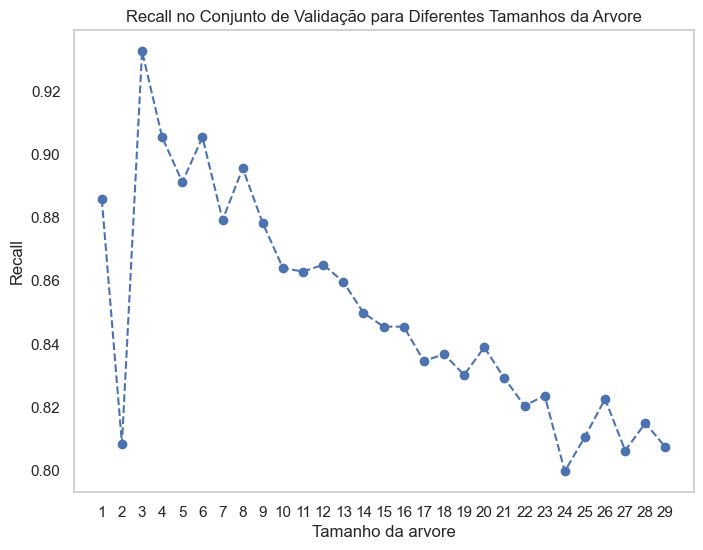

In [34]:

best_depth_sem_width=DecisionTree_best_depth(Xr_train_scaled, Xr_test_scaled, yr_train,yr_test, depth_range)

### 8.3.5 Training and Evaluating the Decision Tree (Without Width)

In [35]:


dt_r = DecisionTreeClassifier(max_depth=best_depth_sem_width,random_state=42)
dt_r.fit(Xr_train_scaled, yr_train)
yr_pred_dt = dt_r.predict(Xr_test_scaled)

evaluate(yr_test, yr_pred_dt, "Decision Tree (sem Width)")



=== Avaliação do modelo: Decision Tree (sem Width) ===

--- Métricas Globais ---
Accuracy : 0.8100481761871989
Precision: 0.8139720978972671
Recall   : 0.8100481761871989
F1-score : 0.8015424227108126

--- Métricas por Classe ---
                    precision    recall  f1-score   support

       Mixed Beans       0.84      0.60      0.70       534
White Haricot Bean       0.80      0.93      0.86       919

          accuracy                           0.81      1453
         macro avg       0.82      0.77      0.78      1453
      weighted avg       0.81      0.81      0.80      1453


Matriz de Confusão:
[[320 214]
 [ 62 857]]


### 8.3.6 Tuning the Value of k for k-NN (Without Width)

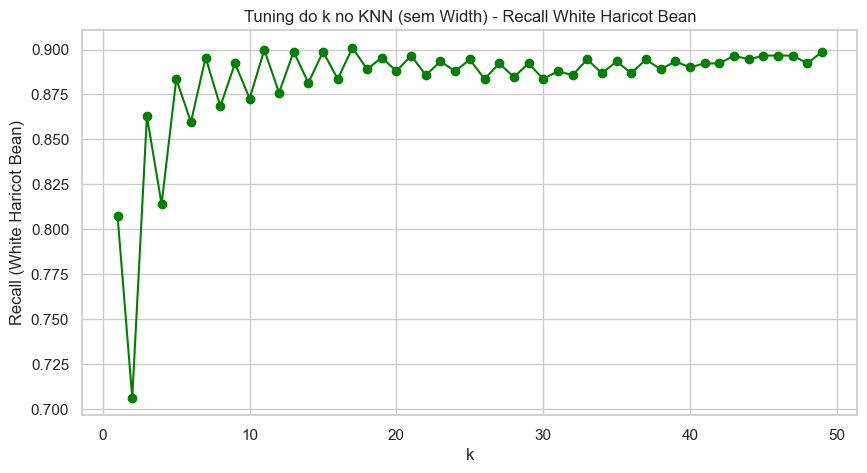

Melhor k para Recall (White Haricot Bean) sem Width: 17 (Recall = 0.9010)


In [36]:
recalls_white_bean_r = []  # Recall para White Haricot Bean (classe 1)
k_values_r = range(1, 50)

for k in k_values_r:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(Xr_train_scaled, yr_train)
    yr_pred_temp = knn_temp.predict(Xr_test_scaled)
    
    # Recall para White Haricot Bean (classe 1)
    recall_per_class = recall_score(yr_test, yr_pred_temp, average=None)
    recalls_white_bean_r.append(recall_per_class[1])

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_values_r, recalls_white_bean_r, marker="o", color='green')
plt.xlabel("k")
plt.ylabel("Recall (White Haricot Bean)")
plt.title("Tuning do k no KNN (sem Width) - Recall White Haricot Bean")
plt.grid(True)
plt.show()

best_k_r = k_values_r[recalls_white_bean_r.index(max(recalls_white_bean_r))]
print(f"Melhor k para Recall (White Haricot Bean) sem Width: {best_k_r} (Recall = {max(recalls_white_bean_r):.4f})")


### 8.3.7 Training and Evaluating the Final k-NN Model (Without Width)


=== Avaliação do modelo: KNN (k=17) sem Width ===

--- Métricas Globais ---
Accuracy : 0.8258774948382657
Precision: 0.8242694688160166
Recall   : 0.8258774948382657
F1-score : 0.8229155496905562

--- Métricas por Classe ---
                    precision    recall  f1-score   support

       Mixed Beans       0.80      0.70      0.75       534
White Haricot Bean       0.84      0.90      0.87       919

          accuracy                           0.83      1453
         macro avg       0.82      0.80      0.81      1453
      weighted avg       0.82      0.83      0.82      1453


Matriz de Confusão:
[[372 162]
 [ 91 828]]


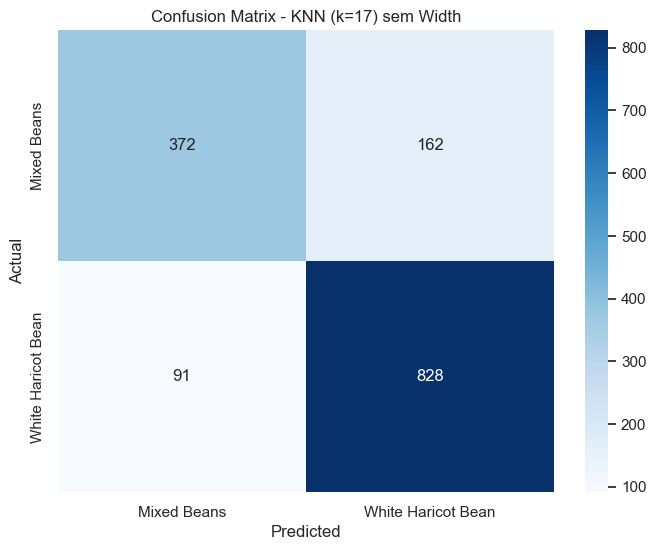

In [37]:
knn_r = KNeighborsClassifier(n_neighbors=best_k_r)
knn_r.fit(Xr_train_scaled, yr_train)


yr_pred_knn = knn_r.predict(Xr_test_scaled)

evaluate(yr_test, yr_pred_knn, f"KNN (k={best_k_r}) sem Width")

# Confusion Matrix visualizada
cm = confusion_matrix(yr_test, yr_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Mixed Beans", "White Haricot Bean"],
            yticklabels=["Mixed Beans", "White Haricot Bean"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - KNN (k={best_k_r}) sem Width')
plt.show()


## 8.4 Logistic Regression

### 8.4.1 Training and Evaluating Logistic Regression

In [38]:

# Criar e treinar o modelo (usa dados normalizados)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Previsões
y_pred_lr = lr.predict(X_test_scaled)

evaluate(y_test, y_pred_lr, "Logistic Regression")

print("Modelo Logistic Regression treinado com sucesso!")


=== Avaliação do modelo: Logistic Regression ===

--- Métricas Globais ---
Accuracy : 0.8210598761183757
Precision: 0.8191377829834372
Recall   : 0.8210598761183757
F1-score : 0.8192173610797576

--- Métricas por Classe ---
                    precision    recall  f1-score   support

       Mixed Beans       0.78      0.71      0.75       534
White Haricot Bean       0.84      0.88      0.86       919

          accuracy                           0.82      1453
         macro avg       0.81      0.80      0.80      1453
      weighted avg       0.82      0.82      0.82      1453


Matriz de Confusão:
[[381 153]
 [107 812]]
Modelo Logistic Regression treinado com sucesso!


## 8.5 PCA

### 8.5.1 Applying PCA and Evaluating k-NN

In [39]:

pca2 = PCA(n_components=2)
X_train_pca2 = pca2.fit_transform(X_train_scaled)
X_test_pca2 = pca2.transform(X_test_scaled)

knn_pca2 = KNeighborsClassifier(n_neighbors=best_k)
knn_pca2.fit(X_train_pca2, y_train)
y_pred_pca2 = knn_pca2.predict(X_test_pca2)

evaluate(y_test, y_pred_pca2, "KNN + PCA(2)")
pca3 = PCA(n_components=3)
X_train_pca3 = pca3.fit_transform(X_train_scaled)
X_test_pca3 = pca3.transform(X_test_scaled)

knn_pca3 = KNeighborsClassifier(n_neighbors=best_k)
knn_pca3.fit(X_train_pca3, y_train)
y_pred_pca3 = knn_pca3.predict(X_test_pca3)

evaluate(y_test, y_pred_pca3, "KNN + PCA(3)")


=== Avaliação do modelo: KNN + PCA(2) ===

--- Métricas Globais ---
Accuracy : 0.8059187887130076
Precision: 0.8038732406895126
Recall   : 0.8059187887130076
F1-score : 0.8016387770897798

--- Métricas por Classe ---
                    precision    recall  f1-score   support

       Mixed Beans       0.78      0.65      0.71       534
White Haricot Bean       0.82      0.89      0.85       919

          accuracy                           0.81      1453
         macro avg       0.80      0.77      0.78      1453
      weighted avg       0.80      0.81      0.80      1453


Matriz de Confusão:
[[349 185]
 [ 97 822]]

=== Avaliação do modelo: KNN + PCA(3) ===

--- Métricas Globais ---
Accuracy : 0.8196834136269787
Precision: 0.8179464750881539
Recall   : 0.8196834136269787
F1-score : 0.8163560781615598

--- Métricas por Classe ---
                    precision    recall  f1-score   support

       Mixed Beans       0.80      0.68      0.74       534
White Haricot Bean       0.83      0

## 9. Final Comparison and Results Summary

### 9.1 Consolidated Performance Table

In [40]:

# ---- Decision Tree COM Width ----
dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec_weighted = precision_score(y_test, y_pred_dt, average='weighted')
dt_rec_weighted = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1_weighted = f1_score(y_test, y_pred_dt, average='weighted')
dt_prec_per_class = precision_score(y_test, y_pred_dt, average=None)
dt_rec_per_class = recall_score(y_test, y_pred_dt, average=None)
dt_f1_per_class = f1_score(y_test, y_pred_dt, average=None)

# ---- Decision Tree SEM Width ----
dt_r_acc = accuracy_score(yr_test, yr_pred_dt)
dt_r_prec_weighted = precision_score(yr_test, yr_pred_dt, average='weighted')
dt_r_rec_weighted = recall_score(yr_test, yr_pred_dt, average='weighted')
dt_r_f1_weighted = f1_score(yr_test, yr_pred_dt, average='weighted')
dt_r_prec_per_class = precision_score(yr_test, yr_pred_dt, average=None)
dt_r_rec_per_class = recall_score(yr_test, yr_pred_dt, average=None)
dt_r_f1_per_class = f1_score(yr_test, yr_pred_dt, average=None)

# ---- KNN COM Width ----
knn_acc = accuracy_score(y_test, y_pred_best_knn)
knn_prec_weighted = precision_score(y_test, y_pred_best_knn, average='weighted')
knn_rec_weighted = recall_score(y_test, y_pred_best_knn, average='weighted')
knn_f1_weighted = f1_score(y_test, y_pred_best_knn, average='weighted')
knn_prec_per_class = precision_score(y_test, y_pred_best_knn, average=None)
knn_rec_per_class = recall_score(y_test, y_pred_best_knn, average=None)
knn_f1_per_class = f1_score(y_test, y_pred_best_knn, average=None)

# ---- KNN SEM Width ----
knn_r_acc = accuracy_score(yr_test, yr_pred_knn)
knn_r_prec_weighted = precision_score(yr_test, yr_pred_knn, average='weighted')
knn_r_rec_weighted = recall_score(yr_test, yr_pred_knn, average='weighted')
knn_r_f1_weighted = f1_score(yr_test, yr_pred_knn, average='weighted')
knn_r_prec_per_class = precision_score(yr_test, yr_pred_knn, average=None)
knn_r_rec_per_class = recall_score(yr_test, yr_pred_knn, average=None)
knn_r_f1_per_class = f1_score(yr_test, yr_pred_knn, average=None)

# ---- Logistic Regression COM Width ----
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec_weighted = precision_score(y_test, y_pred_lr, average='weighted')
lr_rec_weighted = recall_score(y_test, y_pred_lr, average='weighted')
lr_f1_weighted = f1_score(y_test, y_pred_lr, average='weighted')
lr_prec_per_class = precision_score(y_test, y_pred_lr, average=None)
lr_rec_per_class = recall_score(y_test, y_pred_lr, average=None)
lr_f1_per_class = f1_score(y_test, y_pred_lr, average=None)

# Criar tabela com métricas globais e por classe
results = pd.DataFrame({
    "Modelo": [
        "Decision Tree (com Width)",
        "Decision Tree (sem Width)",
        "KNN (com Width)",
        "KNN (sem Width)",
        "Logistic Regression",
    ],
    "Accuracy": [
        dt_acc, dt_r_acc, knn_acc, knn_r_acc, lr_acc
    ],
    "Precision (Global)": [
        dt_prec_weighted, dt_r_prec_weighted, knn_prec_weighted, knn_r_prec_weighted, lr_prec_weighted
    ],
    "Precision (Mixed Beans)": [
        dt_prec_per_class[0], dt_r_prec_per_class[0], knn_prec_per_class[0], knn_r_prec_per_class[0], lr_prec_per_class[0]
    ],
    "Precision (White Haricot)": [
        dt_prec_per_class[1], dt_r_prec_per_class[1], knn_prec_per_class[1], knn_r_prec_per_class[1], lr_prec_per_class[1]
    ],
    "Recall (Global)": [
        dt_rec_weighted, dt_r_rec_weighted, knn_rec_weighted, knn_r_rec_weighted, lr_rec_weighted
    ],
    "Recall (Mixed Beans)": [
        dt_rec_per_class[0], dt_r_rec_per_class[0], knn_rec_per_class[0], knn_r_rec_per_class[0], lr_rec_per_class[0]
    ],
    "Recall (White Haricot)": [
        dt_rec_per_class[1], dt_r_rec_per_class[1], knn_rec_per_class[1], knn_r_rec_per_class[1], lr_rec_per_class[1]
    ],
    "F1-score (Global)": [
        dt_f1_weighted, dt_r_f1_weighted, knn_f1_weighted, knn_r_f1_weighted, lr_f1_weighted
    ],
    "F1-score (Mixed Beans)": [
        dt_f1_per_class[0], dt_r_f1_per_class[0], knn_f1_per_class[0], knn_r_f1_per_class[0], lr_f1_per_class[0]
    ],
    "F1-score (White Haricot)": [
        dt_f1_per_class[1], dt_r_f1_per_class[1], knn_f1_per_class[1], knn_r_f1_per_class[1], lr_f1_per_class[1]
    ]
})

results

,Modelo,Accuracy,Precision (Global),Precision (Mixed Beans),Precision (White Haricot),Recall (Global),Recall (Mixed Beans),Recall (White Haricot),F1-score (Global),F1-score (Mixed Beans),F1-score (White Haricot)
0,Decision Tree (com Width),0.810048,0.813972,0.837696,0.800187,0.810048,0.599251,0.932535,0.801542,0.698690,0.861307
1,Decision Tree (sem Width),0.810048,0.813972,0.837696,0.800187,0.810048,0.599251,0.932535,0.801542,0.698690,0.861307
2,KNN (com Width),0.817619,0.815817,0.794311,0.828313,0.817619,0.679775,0.897715,0.814200,0.732593,0.861619
3,KNN (sem Width),0.825877,0.824269,0.803456,0.836364,0.825877,0.696629,0.900979,0.822916,0.746239,0.867470
4,Logistic Regression,0.821060,0.819138,0.780738,0.841451,0.821060,0.713483,0.883569,0.819217,0.745597,0.861996
